## Importing libraries

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

## Training Image preprocessing

In [15]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


## Validation Image Preprocessing

In [16]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [17]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [18]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[151.25 143.25 154.25]
   [152.75 144.75 155.75]
   [153.   145.   156.  ]
   ...
   [144.25 137.25 145.25]
   [155.25 148.25 156.25]
   [156.5  149.5  157.5 ]]

  [[150.25 142.25 153.25]
   [147.25 139.25 150.25]
   [146.   138.   149.  ]
   ...
   [161.75 154.75 162.75]
   [157.75 150.75 158.75]
   [154.5  147.5  155.5 ]]

  [[149.   141.   152.  ]
   [146.25 138.25 149.25]
   [144.5  136.5  147.5 ]
   ...
   [160.5  153.5  161.5 ]
   [147.25 140.25 148.25]
   [149.25 142.25 150.25]]

  ...

  [[144.25 130.25 143.25]
   [144.25 130.25 143.25]
   [142.   128.   141.  ]
   ...
   [157.5  144.5  154.5 ]
   [152.   139.   149.  ]
   [141.25 128.25 138.25]]

  [[140.75 126.75 139.75]
   [142.25 128.25 141.25]
   [140.25 126.25 139.25]
   ...
   [145.   132.   142.  ]
   [147.5  134.5  144.5 ]
   [136.75 123.75 133.75]]

  [[144.75 130.75 143.75]
   [146.5  132.5  145.5 ]
   [142.5  128.5  141.5 ]
   ...
   [147.75 134.75 144.75]
   [136.75 123.75 133.75]
   [133.5  120.5  13

## Building Model

In [19]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [20]:
model = Sequential()

## Building Convolution Layer

In [21]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [23]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [25]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [26]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [27]:
model.add(Flatten())

In [28]:
model.add(Dense(units=1500,activation='relu'))

In [29]:
model.add(Dropout(0.4))

In [30]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

## Compiling and Training Phase

In [31]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## model training

In [33]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4992s 2s/step - accuracy: 0.5922 - loss: 1.3916 - val_accuracy: 0.8295 - val_loss: 0.5317
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4944s 2s/step - accuracy: 0.8584 - loss: 0.4467 - val_accuracy: 0.9196 - val_loss: 0.2582
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 16742s 8s/step - accuracy: 0.9156 - loss: 0.2634 - val_accuracy: 0.9341 - val_loss: 0.2180
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 6663s 3s/step - accuracy: 0.9388 - loss: 0.1852 - val_accuracy: 0.9335 - val_loss: 0.2053
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 5563s 3s/step - accuracy: 0.9550 - loss: 0.1380 - val_accuracy: 0.9583 - val_loss: 0.1281
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 6299s 3s/step - accuracy: 0.9655 - loss: 0.1068 - val_accuracy: 0.9575 - val_loss: 0.1384
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 14033s 6s/step - accuracy: 0.9695 - loss: 0.0910 - val_accuracy: 0.9550 - val_loss: 0.1443
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 5392s 2s/step - accuracy: 0.9752

## Model Evaluation

In [35]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1161s 528ms/step - accuracy: 0.9922 - loss: 0.0241


In [36]:
print(train_loss,train_acc)

0.024063246324658394 0.9922469854354858


## Model on Validation set

In [38]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 295s 535ms/step - accuracy: 0.9671 - loss: 0.1111


In [39]:
print(val_loss,val_acc)

0.11107432842254639 0.9671067595481873


## Saving Model

In [41]:
model.save("trained_model.keras")

In [42]:
training_history.history

{'accuracy': [0.592246949672699,
  0.8583967685699463,
  0.9156270027160645,
  0.9387580752372742,
  0.9549754858016968,
  0.9654883146286011,
  0.9695141911506653,
  0.9751760363578796,
  0.9790881276130676,
  0.981677234172821],
 'loss': [1.3916188478469849,
  0.44667690992355347,
  0.2633589506149292,
  0.18519705533981323,
  0.1379828155040741,
  0.10678456723690033,
  0.09099125862121582,
  0.07529914379119873,
  0.06644666194915771,
  0.056950949132442474],
 'val_accuracy': [0.8295014500617981,
  0.9196448922157288,
  0.9340997338294983,
  0.9335306286811829,
  0.958285927772522,
  0.9575461149215698,
  0.9549852013587952,
  0.9640336632728577,
  0.94514000415802,
  0.9671067595481873],
 'val_loss': [0.531749427318573,
  0.25821158289909363,
  0.2180468589067459,
  0.20534883439540863,
  0.12806271016597748,
  0.13838838040828705,
  0.1443040668964386,
  0.1129075437784195,
  0.19376972317695618,
  0.11107436567544937]}

## Recording History in json

In [43]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [44]:
training_history.history['val_accuracy']

[0.8295014500617981,
 0.9196448922157288,
 0.9340997338294983,
 0.9335306286811829,
 0.958285927772522,
 0.9575461149215698,
 0.9549852013587952,
 0.9640336632728577,
 0.94514000415802,
 0.9671067595481873]

## Accuracy Visualization

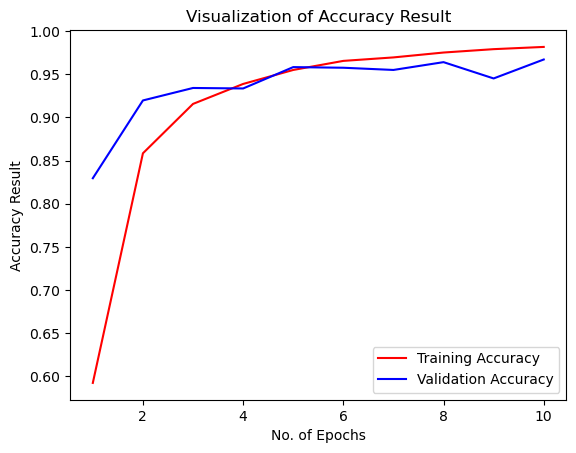

In [45]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [46]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [50]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [51]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 298s 540ms/step


(array([[9.99752700e-01, 3.85199382e-05, 1.80166140e-08, ...,
         6.33179897e-10, 3.14991838e-10, 1.17640724e-07],
        [9.99893427e-01, 1.03159000e-04, 1.41742187e-10, ...,
         3.61331762e-15, 4.68759623e-12, 1.50351292e-12],
        [9.99985814e-01, 1.11533018e-05, 8.37293168e-09, ...,
         2.43088405e-12, 4.39711566e-11, 3.64260200e-09],
        ...,
        [1.88140377e-17, 7.97030283e-21, 1.27563128e-14, ...,
         7.39813201e-17, 2.56607639e-17, 1.00000000e+00],
        [1.76580809e-13, 1.32171956e-17, 1.70656512e-12, ...,
         2.41698236e-13, 4.13362920e-14, 1.00000000e+00],
        [2.75162019e-19, 5.05604012e-21, 1.29188522e-17, ...,
         4.82677796e-18, 2.62121466e-16, 1.00000000e+00]],
       shape=(17572, 38), dtype=float32),
 (17572, 38))

In [52]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [53]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [54]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [55]:
from sklearn.metrics import classification_report,confusion_matrix

In [56]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.91      0.95       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.97      0.98       440
                                   Apple___healthy       0.98      0.96      0.97       502
                               Blueberry___healthy       0.97      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.96      0.93       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.92      0.

In [57]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[459,   8,   0, ...,   0,   0,   1],
       [  0, 485,   0, ...,   0,   0,   0],
       [  0,   1, 427, ...,   1,   0,   1],
       ...,
       [  0,   0,   0, ..., 488,   0,   0],
       [  0,   0,   0, ...,   0, 443,   0],
       [  0,   0,   0, ...,   0,   0, 479]], shape=(38, 38))

### Confusion Matrix Visualization

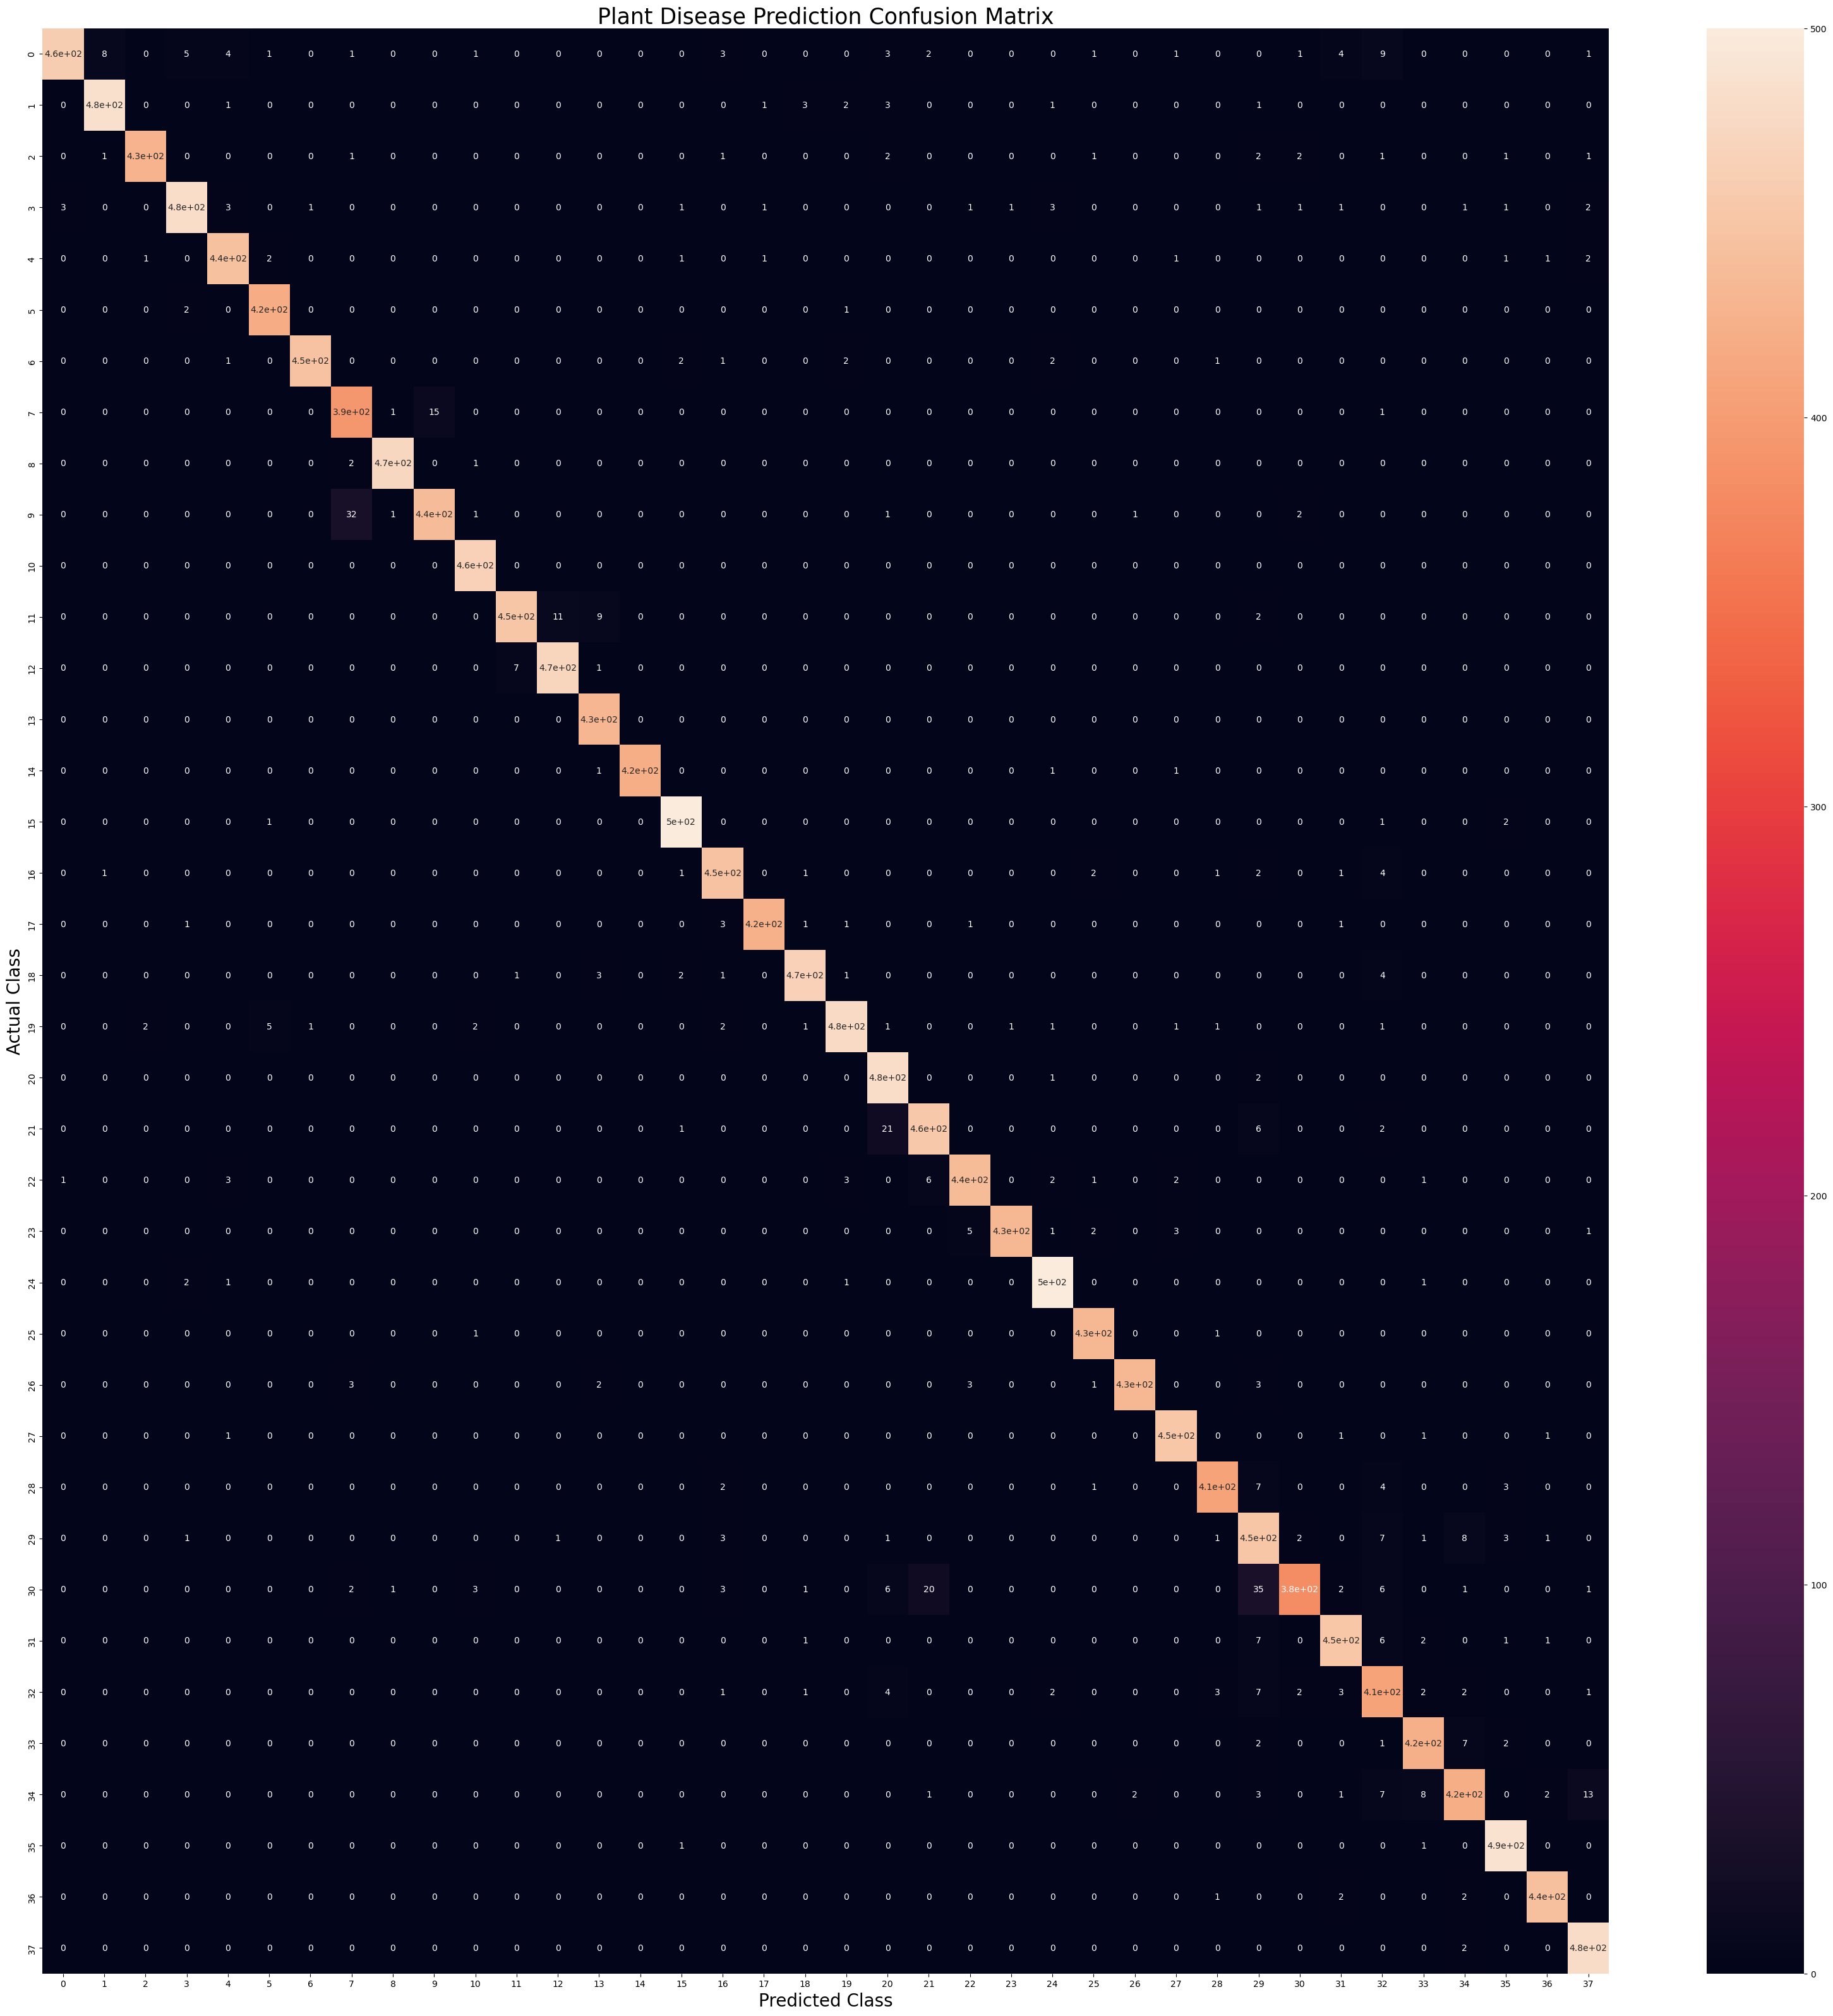

In [58]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()